# Практикум по программированию на языке Python

## <font color='lilac'>Занятие 5: Инструменты для машинного обучения</font>

#### Мурат Апишев (mel-lain@yandex.ru)
#### Москва, 2026

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt

### <font color='lilac'>Основы</font>

- Какие есть постановки задач машинного обучения?
- Что такое обучение с учителем?
- Что такое обучение без учителя?
- Что такое минимизация эмпирического риска?
- Что такое переобучение, как с ним бороться?
- Что такое кроссвалидация? Какие бывают виды?

### <font color='lilac'>Библиотека sklearn</font>

- Стандартная и основная библиотека для general ML в Python
- Реализует многие используемые алгоритмы и модели, иногда в качестве обёртки
- Содержит множество полезных утилит для работы с данными, подбора параметров модели и оценивания качества
- Имеет понятный унифицированный интерфейс
- Использует NumPy и SciPy

### <font color='lilac'>Напоминание: линейные модели</font>

- Модель имеет вид $a(x, w) = \langle x, w \rangle$
- В задаче классификации ответ $y$ принадлежит дискретному множеству
- В задаче регрессии $y \in \mathbb{R}$
- Вид модели определяет дифференцируемая функция потерь $\mathcal{L}(y, a(x, w))$

- Линейная регрессия: $\mathcal{L} = (y - a(x, w))^2$
- В классификации используются различные аппроксимации пороговой функции потерь:
    - Логистическая (лог-регрессия): $\mathcal{L} = \log(1 + \exp(-\langle x, w \rangle y))$
    - Кусочно-линейная (линейный SVM): $\mathcal{L} = (1 - \langle x, w \rangle y)_+$
    - Ещё несколько других

### <font color='lilac'>Напоминание: метрики качества</font>

- Функционал качества $\ne$ метрика качества
- Функционал удобно дифференцировать, его вид определяет свойства модели
- Метрика - внешний объективный критерий качества решения задачи, от модели обычно не зависит

- Популярные метрики для задачи классификации:
    - accuracy
    - precision/recall
    - F1-measure
    - ROC AUC
    - AUC PR

- Популярные метрики для задачи регрессии:
    - MAE
    - MSE
    - RMSE
    - SMAPE
    - $r^2$

### <font color='lilac'>Напоминание: регуляризация</font>

- Регуляризация смещает решение, но делает его более устойчивым
- Варианты:
    - L1: уменьшение числа ненулевых весов (отбор признаков)
    - L2: распределение весов между признаками
    - Их взвешенная сумма

### <font color='lilac'>Лог-регрессия в sklearn</font>

In [4]:
import seaborn
from sklearn.linear_model import LogisticRegression

df = seaborn.load_dataset('iris')

X = df[df.columns[: -1]].values
y = df['species'].values

model = LogisticRegression(solver='liblinear', multi_class='ovr')
model.fit(X, y)

preds = model.predict(df[df.columns[: -1]].values)

print('Train accuracy: {}'.format(sum([i == j for i, j in zip(preds, y)]) / float(len(preds))))

Train accuracy: 0.96


### <font color='lilac'>Выбор модели</font>

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Perceptron
from sklearn.linear_model import SGDClassifier
from sklearn.svm import LinearSVC

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import Lasso
from sklearn.linear_model import Lars
from sklearn.linear_model import SGDRegressor
from sklearn.svm import LinearSVR

### <font color='lilac'>Выбор гиперпараметров</font>

In [6]:
model = LogisticRegression(penalty='l2',       # or 'l1'
                           C=1.0,              # or any float > 0.0 (less == stronger penalty)
                           class_weight=None,  # or dict, or 'balanced'
                           solver='liblinear', # or 'lbfgs', 'sag', 'saga'
                           multi_class='ovr'   # or 'multinomial'
                           )

### <font color='lilac'>Разбиение на обучение и тест</font>

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

model = LogisticRegression(solver='liblinear', multi_class='ovr')
model.fit(X_train, y_train)

(135, 4)
(135,)
(15, 4)
(15,)


LogisticRegression(multi_class='ovr', solver='liblinear')

### <font color='lilac'>Замер качества на тесте</font>

In [25]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

preds = model.predict(X_test)
print('Test Accuracy: {}'.format(accuracy_score(y_test, preds)))
print('Test f1-score: {}\n'.format(f1_score(y_test, preds, average='macro')))

probs = model.predict_proba(X_test)
print(probs[: 5])

Test Accuracy: 0.9333333333333333
Test f1-score: 0.9326599326599326

[[8.77083996e-01 1.22236894e-01 6.79109661e-04]
 [8.80930742e-01 1.18800882e-01 2.68376361e-04]
 [8.29153917e-01 1.69770903e-01 1.07518037e-03]
 [5.38513538e-02 4.62162512e-01 4.83986134e-01]
 [6.02829834e-03 4.71657951e-01 5.22313751e-01]]


В `sklearn.metrics` есть десятки разнообразных метрик для различных задач

### <font color='lilac'>Перебор гиперпараметров по сетке</font>

In [43]:
from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV

model = GridSearchCV(LogisticRegression(solver='liblinear', multi_class='ovr'),
                     cv=5,
                     param_grid={"C": [0.5, 1.0, 10.0, 100.0]},
                     scoring=make_scorer(f1_score, **{'average':'macro'}))

model.fit(X_train, y_train)
print(f1_score(y_test, model.predict(X_test), average='macro'))
model

0.9326599326599326


GridSearchCV(cv=5,
             estimator=LogisticRegression(multi_class='ovr',
                                          solver='liblinear'),
             param_grid={'C': [0.5, 1.0, 10.0, 100.0]},
             scoring=make_scorer(f1_score, response_method='predict', average=macro))

### <font color='lilac'>Анализ весов признаков</font>

- Интерпретируемость доступная благодаря тому, что мы используем линейную модель
- Важно, чтобы признаки имели один масштаб значений

In [13]:
import pandas as pd
df = pd.DataFrame(data=model.best_estimator_.coef_,
                  columns=df.columns[: -1],
                  index=model.classes_)

df

,sepal_length,sepal_width,petal_length,petal_width
setosa,0.936643,3.054329,-4.849467,-2.419512
versicolor,0.213950,-3.088029,1.144720,-2.913226
virginica,-3.836725,-3.116696,6.009686,9.748844


### <font color='lilac'>Генерация модельных данных</font>

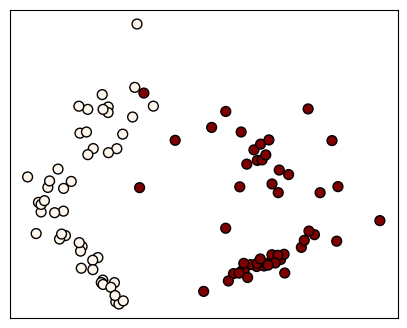

In [173]:
from sklearn.datasets import make_classification

X, y = make_classification(n_features=2, n_classes=2, n_samples=100, n_redundant=0, random_state=1)

plt.figure(1, figsize=(5, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, zorder=10, cmap=plt.cm.OrRd, s=50, edgecolors='k')
plt.xticks(())
plt.yticks(())
plt.show()

In [168]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

# helper function for visualization

# level parameter should be tuned by hand for more convenient sight

def plot_results(model, X, y, level=1.0, cmap_objects=plt.cm.OrRd, cmap_plot=plt.cm.OrRd,
                 use_decision_function=True, plot_logreg=False):
    # plot the line, the points, and the nearest vectors to the plane
    plt.figure(1, figsize=(5, 4))
    plt.clf()

    if hasattr(model, "support_vectors_"):
        plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=150,
                    facecolors='none', zorder=10, edgecolors='k')
    plt.scatter(X[:, 0], X[:, 1], c=y, zorder=10, cmap=cmap_objects, s=50)

    plt.axis('tight')

    x_min, x_max = np.min(X[:, 0]), np.max(X[:, 0])
    x_bound = np.abs(x_max - x_min) / 10.0
    x_min -= x_bound
    x_max += x_bound

    y_min, y_max = np.min(X[:, 1]), np.max(X[:, 1])
    y_bound = np.abs(y_max - y_min) / 10.0
    y_min -= y_bound
    y_max += y_bound

    XX, YY = np.mgrid[x_min:x_max:500j, y_min:y_max:500j]

    use_Z = False
    if hasattr(model, "decision_function") and use_decision_function:
        Z = model.decision_function(np.c_[XX.ravel(), YY.ravel()])
        use_Z = True
    elif hasattr(model, "predict"):
        Z = model.predict(np.c_[XX.ravel(), YY.ravel()])
        use_Z = True

    # Put the result into a color plot
    if use_Z:
        Z = Z.reshape(XX.shape)
        plt.figure(1, figsize=(7, 6))
        plt.pcolormesh(XX, YY, Z, cmap=cmap_plot)
        if hasattr(model, "support_vectors_"):
            plt.contour(XX, YY, Z, colors=['k', 'k', 'k'], linestyles=['--', '-', '--'], levels=[-level, 0, level])
        elif plot_logreg:
            plt.contour(XX, YY, Z, colors=['k', 'k', 'k'], linestyles=['--', '-', '--'], levels=[-1e-10, 0, 1e+10])

    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)

    plt.xticks(())
    plt.yticks(())
    plt.show()

### <font color='lilac'>Линейный SVM</font>

Train f1-score: 0.98


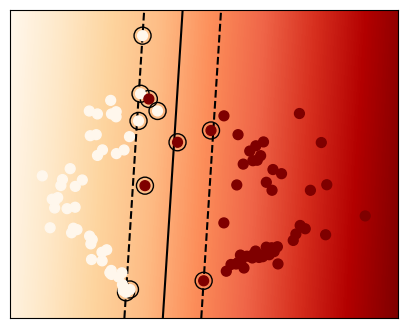

In [170]:
import sklearn.svm as svm

model = svm.SVC(kernel='linear', C=1.0)
model.fit(X, y)
print(f'Train f1-score: {round(f1_score(model.predict(X), y), 3)}')
plot_results(model, X, y)

### <font color='lilac'>Лог-регрессия</font>

Train f1-score: 0.98


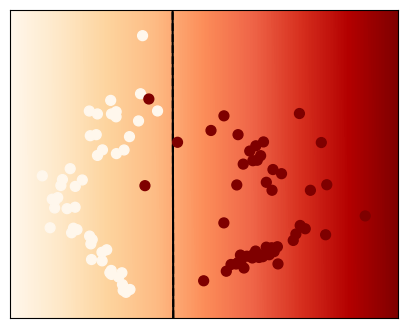

In [171]:
model = LogisticRegression(solver='liblinear')
model.fit(X, y)
print(f'Train f1-score: {round(f1_score(model.predict(X), y), 3)}')
plot_results(model, X, y, plot_logreg=True)

### <font color='lilac'>Работа с нелинейными данными</font>

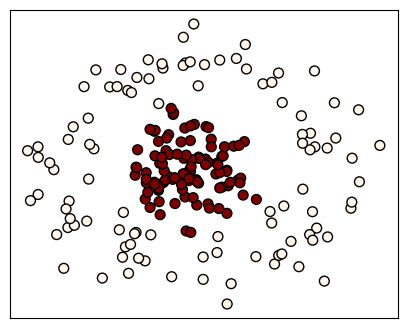

In [174]:
from sklearn.datasets import make_circles

X, y = make_circles(noise=0.2, factor=0.2, random_state=1, n_samples=200)

plt.figure(1, figsize=(5, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, zorder=10, cmap=plt.cm.OrRd, s=50, edgecolors='k')
plt.xticks(())
plt.yticks(())
plt.show()

Train f1-score: 0.556


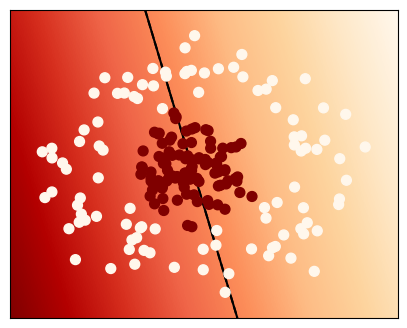

In [175]:
model = LogisticRegression(solver='liblinear')
model.fit(X, y)
print(f'Train f1-score: {round(f1_score(model.predict(X), y), 3)}')
plot_results(model, X, y, plot_logreg=True)

### <font color='lilac'>Ядровой SVM</font>

Train f1-score: 0.995


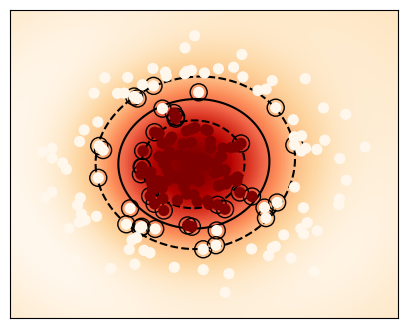

In [176]:
model = svm.SVC(kernel='rbf', C=1.0, gamma=1.0)
model.fit(X, y)
print(f'Train f1-score: {round(f1_score(model.predict(X), y), 3)}')
plot_results(model, X, y, level=0.98)

### <font color='lilac'>Полиномиальные признаки</font>

In [121]:
from sklearn.preprocessing import PolynomialFeatures

# x, y -> x, y, x^2, y^2, xy
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_poly = poly.fit_transform(X)

model = LogisticRegression()
model.fit(X_poly, y)

print(f'Train f1-score: {round(f1_score(model.predict(X_poly), y), 3)}')

Train f1-score: 0.976


### <font color='lilac'>Данные для линейных моделей</font>

- __Несбалансированность данных нежелательна__
    - простейший способ борьбы - сэмплировать объекты доминирующего класса
    - в разных задачах бывает возможным генерировать объекты, похожие на объекты меньшего класса

- __Признаки объектов для линейных моделей нужно нормировать__
    - веса становятся интерпретируемыми
    - градиентные методы оптимизации лучше сходятся

- __Влияние выбросов__
    - на линейную регрессию - сильное
    - на логистическую регрессию - умеренное
    - на линейный SVM - сильное, если выброс стал опорным вектором

### <font color='lilac'>Линейная регрессия и выбросы</font>

In [180]:
import matplotlib.pyplot as plt

def plot_regression(X_train, y_train, y_train_pred, X_test, y_test, y_test_pred):
    fig, ax = plt.subplots(ncols=2, figsize=(10, 4), sharex=True, sharey=True)
    
    ax[0].scatter(X_train, y_train, label="Train data points")
    ax[0].plot(
        X_train,
        y_train_pred,
        linewidth=3,
        color="tab:orange",
        label="Model predictions",
    )
    ax[0].set(xlabel="Feature", ylabel="Target", title="Train set")
    ax[0].legend()
    
    ax[1].scatter(X_test, y_test, label="Test data points")
    ax[1].plot(X_test, y_test_pred, linewidth=3, color="tab:orange", label="Model predictions")
    ax[1].set(xlabel="Feature", ylabel="Target", title="Test set")
    ax[1].legend()
    
    fig.suptitle("Linear Regression")
    
    plt.show()

In [181]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X, y = load_diabetes(return_X_y=True)
X = X[:, [2]]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=20, shuffle=False)

MSE: 2548.07


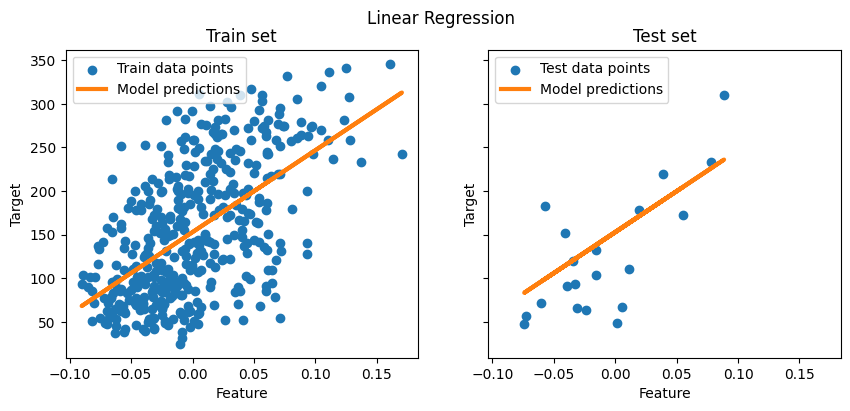

In [182]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f'MSE: {round(mean_squared_error(y_test, y_pred), 2)}')
plot_regression(
    X_train=X_train,
    y_train=y_train,
    y_train_pred=model.predict(X_train),
    X_test=X_test,
    y_test=y_test,
    y_test_pred=y_pred,
)

- Делаем один объект выбросом:

In [183]:
X_train[-1] *= 100

MSE: 4240.64


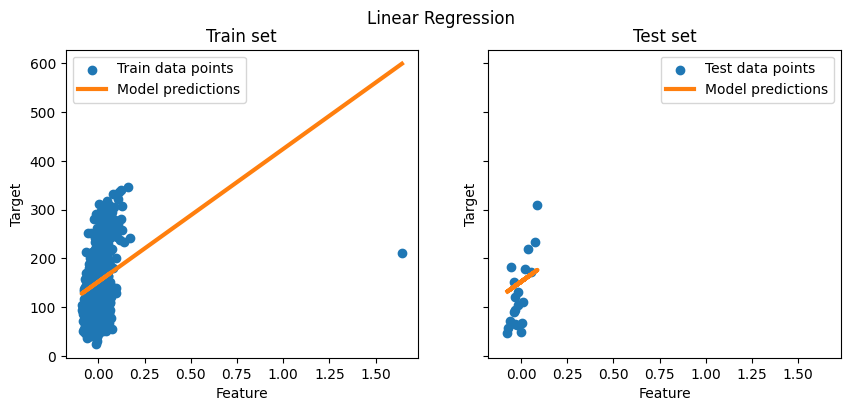

In [184]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"MSE: {round(mean_squared_error(y_test, y_pred), 2)}")
plot_regression(
    X_train=X_train,
    y_train=y_train,
    y_train_pred=model.predict(X_train),
    X_test=X_test,
    y_test=y_test,
    y_test_pred=y_pred,
)

### <font color='lilac'>Напоминание: метрические модели</font>

- Основываются на расстояних между объектами
- Основные функции расстояния:
    - Евклидово расстояние: $p(x, y) = \sqrt{\sum_i(x_i - y_i)^2}$
    - Манхэттенское расстояние: $p(x, y) = \sum_i|x_i - y_i|$
    - Расстояние Чебышева: $p(x, y) = \max(|x_i - y_i|)$
    - Косинусное расстояние: $p(x, y) = \cfrac{\langle x, y \rangle}{||x|| * ||y||}$
- Могут использоваться как для обучения с учителем, так и без
- Самые известные представители: kNN и k-means

### <font color='lilac'>Напоминание: метрические модели</font>

- Результаты работы сильно зависят от выбора функции близости и признакового описания
- Признаки нуждаются в нормализации:
    - можно делать _мини-макс нормализацию_: $\hat x = \cfrac{x - \min(x)}{\max(x) - \min(x)}$
    - можно _Z-нормализацию_: $\hat x = \cfrac{x - \mathbb{E}(x)}{\sigma(x)}$
- kNN можно модифицировать для ускорения поиска ближайших соседей (возможно приближённого) 
- возможны различные варианты учёта соседей и расстояний до них  
- kNN может использоваться на практике для быстрой фильтрации кандидатов на более точную обработку

### <font color='lilac'>kNN на линейно неразделимых данных</font>

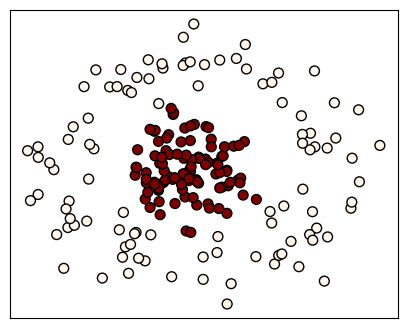

In [186]:
from sklearn.datasets import make_circles

X, y = make_circles(noise=0.2, factor=0.2, random_state=1, n_samples=200)

plt.figure(1, figsize=(5, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, zorder=10, cmap=plt.cm.OrRd, s=50, edgecolors='k')
plt.xticks(())
plt.yticks(())
plt.show()

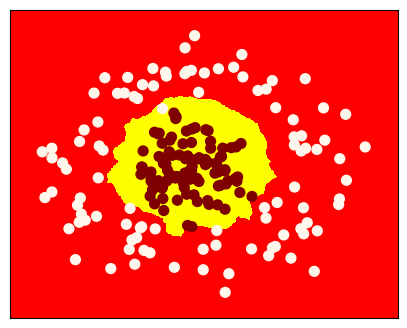

In [187]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X, y)
plot_results(model, X, y, cmap_plot=plt.cm.autumn)

### <font color='lilac'>Кластеризация k-means</font>

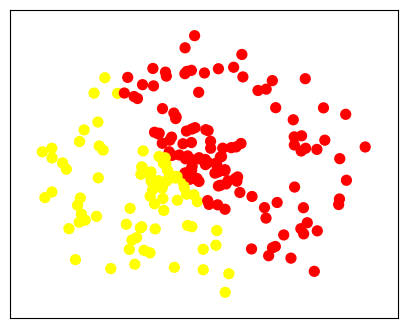

In [188]:
from sklearn.cluster import k_means

model = k_means(X, n_clusters=2)
labels = model[1]
plot_results(model, X, labels, cmap_objects=plt.cm.autumn)

### <font color='lilac'>Частичное обучение</font>

- Иногда у нас есть какое-то количество размеченных примеров
- Можно ими воспользоваться, для этого есть модуль `sklearn.semi_supervised`
- Подготовка данных:

In [189]:
import numpy.random as rnd

indices = rnd.choice(range(len(y)), int(len(y) / 10), replace=False)
y_masked = np.full(len(y), -1)
y_masked[indices] = y[indices]

### <font color='lilac'>Частичное обучение</font>

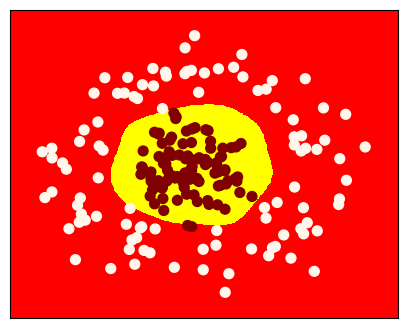

In [190]:
from sklearn.semi_supervised import LabelSpreading

model = LabelSpreading()
model.fit(X, y_masked)
plot_results(model, X, y, cmap_plot=plt.cm.autumn)

### <font color='lilac'>Кластеризация DBSCAN</font>

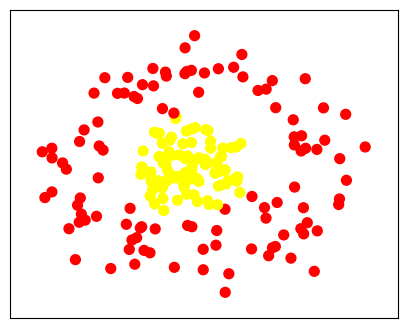

In [191]:
from sklearn.cluster import DBSCAN

model = DBSCAN(eps=0.2, min_samples=10).fit(X)
labels = model.labels_
plot_results(model, X, labels, cmap_objects=plt.cm.autumn)

- Но ошибиться с гиперпараметром очень легко:

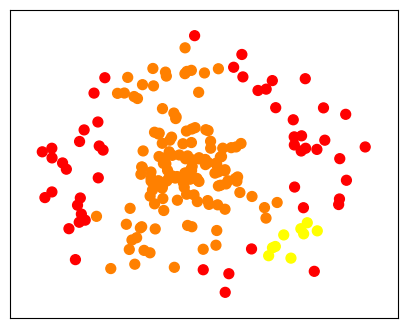

In [192]:
model = DBSCAN(eps=0.3, min_samples=10).fit(X)
labels = model.labels_
plot_results(model, X, labels, cmap_objects=plt.cm.autumn)

### <font color='lilac'>Напоминание: решающие деревья (логические модели)</font>

- Decision Tree представляет собой бинарное дерево
    - в узлах - условия расшепления выборки
    - в листах - ответы модели
- Как правило, в жизни используются деревья с условием расщепления в виде бинарного порога на значениях одного признака
- Деревья не используют расстояния между объектами, только взаимные положения на осях признаков
- Различные критерии оценки качества расщепления приводят к различным моделям
- Полноценное обучение дерева - вычислительно сложная задача, поэтому используются жадные алгоритмы

### <font color='lilac'>Напоминание: решающие деревья (логические модели)</font>

- __Преимущества__:
    - простые и отлично интерпретируемые
    - перебор по значению критерия расщепления обеспечивает встроенный отбор признаков
    - устойчивыми к монотонным преобразованиям признаков и позволяет работать с признаками различной природы
    - Деревья сильно переобучаются, поэтому в жизни используются редко
    - Зато в составе композиций работаю очень круто

- __Недостатки__:
    - склонны к переобучению
    - модель получается сложной при аппроксимации разделяющей поверхности, не параллельной признаковым осям координат
    - добавление новых объектов требует переобучения дерева

### <font color='lilac'>Напоминание: композиции над решающими деревьями</font>

- Сами по себе решающие деревья используются только в простейших задачах, требующих интерпретируемости
- А вот композиции деревьев оказались очень мощными моделями, способными решать сложные задачи
- Два основных типа композиций деревьев:
    - Случайный лес (Random Forest) - композиция сложных деревьев (Bagging + Random Subspace Method)
    - Градиентный бустинг - композиция простых деревьев, каждое следующее дерево обучается исправлять ошибки предшественников
- Отдельной разновидностью случайных лесов являются Extremely Randomized Trees - модификация, в которой выбор порога для каждого признака-кандидата в дереве производится случайно, а не перебором

### <font color='lilac'>Напоминание: Out-of-Bag Score для случайного леса</font>

- Каждое дерево обучается по подмножеству объектов    
- Для каждого дерева есть существенное подмножество выборки, которое является контрольным для этого дерева
- По подмножеству деревьев, которые не использовали объект, посчитать качество на нем
- Это даёт возможность не использовать выделенную валидационную выборку

### <font color='lilac'>Основные библиотеки</font>

- Библиотеки общего назначения:
    - `sklearn`
- Библиотеки для обучения градиентного бустинга над решающими деревьями:
    - `XGBoost`
    - `LightGBM`
    - `CatBoost`
- Отличаются
    - скоростью
    - способом организацией параллелизма
    - способом оптимизации обучения и разбиений деревьев
    - способом обработки категориальных признаков

### <font color='lilac'>Композиции в sklearn</font>

In [133]:
from sklearn.ensemble import VotingClassifier

from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import BaggingRegressor

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import ExtraTreesRegressor

from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import AdaBoostRegressor

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import GradientBoostingRegressor

### <font color='lilac'>Подготовка данных</font>

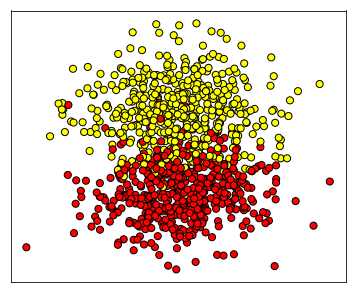

In [160]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=1000, n_features=2, n_informative=1, n_redundant=0,
                           n_classes=2, random_state=9, n_clusters_per_class=1, shuffle=True)

plt.figure(1, figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, zorder=10, cmap=plt.cm.autumn, s=50, edgecolors='k')
plt.xticks(())
plt.yticks(())
plt.show()

In [170]:
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings("ignore")

def plot_results(model, X, y, level=1.0, cmap=plt.cm.autumn, use_decision_function=True):
    # plot the line, the points, and the nearest vectors to the plane
    plt.figure(1, figsize=(6, 5))
    plt.clf()

    plt.scatter(X[:, 0], X[:, 1], c=y, zorder=10, cmap=cmap, s=50, edgecolors='k')

    plt.axis('tight')

    x_min, x_max = np.min(X[:, 0]), np.max(X[:, 0])
    x_bound = np.abs(x_max - x_min) / 10.0
    x_min -= x_bound
    x_max += x_bound

    y_min, y_max = np.min(X[:, 1]), np.max(X[:, 1])
    y_bound = np.abs(y_max - y_min) / 10.0
    y_min -= y_bound
    y_max += y_bound

    XX, YY = np.mgrid[x_min:x_max:300j, y_min:y_max:300j]

    if hasattr(model, "decision_function") and use_decision_function:
        Z = model.decision_function(np.c_[XX.ravel(), YY.ravel()])
    else:
        Z = model.predict(np.c_[XX.ravel(), YY.ravel()])

    # Put the result into a color plot
    Z = Z.reshape(XX.shape)
    plt.figure(1, figsize=(6, 5))
    plt.pcolormesh(XX, YY, Z, cmap=ListedColormap(['#ff9999','#fff899']))

    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)

    plt.xticks(())
    plt.yticks(())
    plt.show()

### <font color='lilac'>Обучение классификатора Random Forest</font>

In [162]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(n_estimators=250, random_state=0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

forest.fit(X_train, y_train)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='gini',
                       max_depth=None, max_features='auto', max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=250,
                       n_jobs=None, oob_score=False, random_state=0, verbose=0,
                       warm_start=False)

### <font color='lilac'>Основные гиперпараметры случайного леса в sklearn</font>

- `n_estimators` - число деревьев в лесу
- `criterion` - критерий ветвления
- `min_samples_split` - минимальное число объектов в листе, допускающее деление
- `min_samples_leaf` - минимальное число элементов в листе
- `max_features` - максимально число перебираемых признаков при поиске лучшего ветвления
- `oob_score` - нужно ли использовать Out-of-bag score для оценивания обобщающей способности леса
- `n_jobs` - число параллельных потоков

### <font color='lilac'>Визуализация результатов</font>

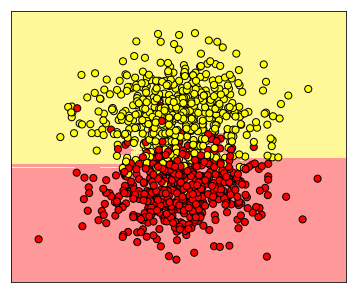

In [171]:
plot_results(forest, X, y)

### <font color='lilac'>Важность признаков</font>

- Помним, что выборка генерировалась с игнорированием одного из признаков

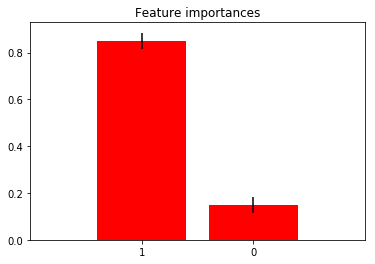

In [149]:
importances = forest.feature_importances_
std = np.std([tree.feature_importances_ for tree in forest.estimators_], axis=0)
indices = np.argsort(importances)[::-1]

plt.figure()
plt.title("Feature importances")
plt.bar(range(X.shape[1]), importances[indices],
       color="r", yerr=std[indices], align="center")
plt.xticks(range(X.shape[1]), indices)
plt.xlim([-1, X.shape[1]])
plt.show()

### <font color='lilac'>Out-of-Bag score</font>

- Для каждого объекта ответ считается по деревьям, в обучении которых он не участвовал, далее все усредняется

In [150]:
from sklearn.metrics import accuracy_score

oob_accuracy = []
test_accuracy = []
for i in range(10, 400, 10):
    forest = RandomForestClassifier(n_estimators=i, random_state=0, oob_score=True)
    forest.fit(X_train, y_train)

    oob_accuracy.append(forest.oob_score_)
    y_pred = forest.predict(X_test)
    test_accuracy.append(accuracy_score(y_test, y_pred))

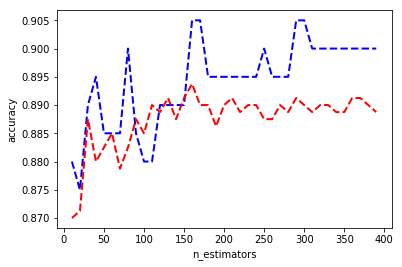

In [152]:
plt.xlabel("n_estimators")
plt.ylabel("accuracy")
plt.plot(range(10, 400, 10), test_accuracy, 'b--',
         range(10, 400, 10), oob_accuracy, 'r--', linewidth=2)
plt.show()

### <font color='lilac'>GB в sklearn</font>

- Не самое эффективное по времени и памяти решение
- Лучше вместо этой реализации использовать xgboost или catboost
- Посмотрим для общего развития, принципиально ничего нового нет

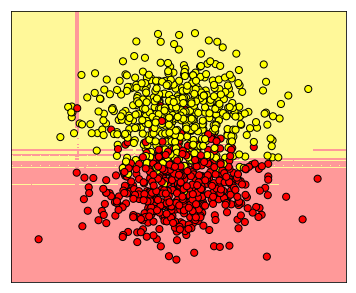

In [172]:
from sklearn.ensemble import GradientBoostingClassifier

gbc = GradientBoostingClassifier(n_estimators=250, random_state=0)
gbc.fit(X_train, y_train)
plot_results(gbc, X, y)

### <font color='lilac'>Основные параметры градиентного бустинга в sklearn</font>

- `loss` - оптимизируемый функционал
- `learning_rate` - скорость обучения (по деревьям)
- `n_estimators` - число деревьев
- `subsample` - доля объектов для обучения каждого дерева
- `criterion` - критерий качества разбиения
- `min_samples_split` - минимальное число объектов в листе, допускающее деление
- `min_samples_leaf` - минимальное число элементов в листе
- `max_depth` - максимальная глубина каждого дерева
- `min_impurity_decrease` - минимальный выигрыш от разбиения, допускающий его проведение
- `max_features` - максимально число перебираемых признаков при поиске лучшего ветвления

### <font color='lilac'>Сгенерируем более сложные данные</font>

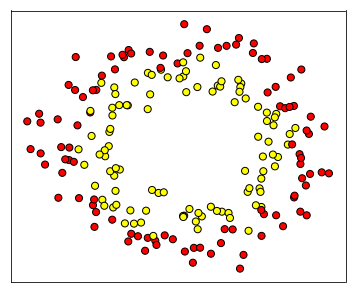

In [173]:
from sklearn.datasets import make_circles

X, y = make_circles(n_samples=200, shuffle=True, factor=0.7, noise=0.1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

plt.figure(1, figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, zorder=10, cmap=plt.cm.autumn, s=50, edgecolors='k')
plt.xticks(())
plt.yticks(())
plt.show()

### <font color='lilac'>Запустим xgboost</font>

- быстрая (параллельная), экономичная по памяти
- может запускаться на разных платформах и распределённых фреймворках
- допускает ускорение обучения с помощью GPU

0.75


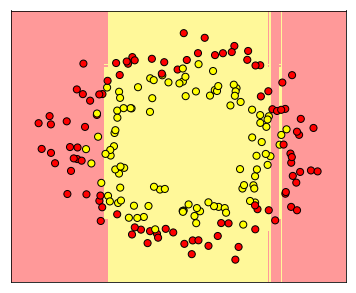

In [174]:
import xgboost as xgb

xgbc = xgb.XGBClassifier(objective='reg:linear', colsample_bytree=0.3,
                         learning_rate=0.1, max_depth=3,
                         alpha=10, n_estimators=10)
xgbc.fit(X_train, y_train)
print(accuracy_score(y_test, xgbc.predict(X_test)))
plot_results(xgbc, X, y)

### <font color='lilac'>Подбор гиперпараметров</font>

0.9


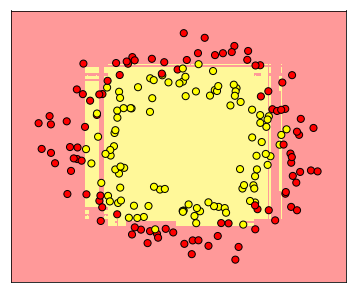

In [175]:
xgbc = xgb.XGBClassifier(objective='reg:linear', colsample_bytree=0.3,
                         learning_rate=0.05, max_depth=3,
                         alpha=10, n_estimators=100)
xgbc.fit(X_train, y_train)

print(accuracy_score(y_test, xgbc.predict(X_test)))
plot_results(xgbc, X, y)

0.925


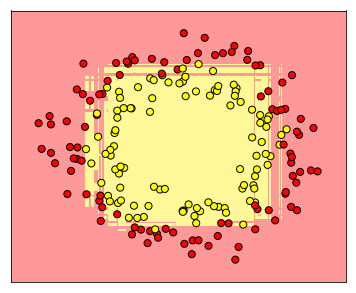

In [176]:
xgbc = xgb.XGBClassifier(objective='reg:linear', colsample_bytree=0.3,
                         learning_rate=0.001, max_depth=3,
                         alpha=10, n_estimators=10000)
xgbc.fit(X_train, y_train)

print(accuracy_score(y_test, xgbc.predict(X_test)))
plot_results(xgbc, X, y)

### <font color='lilac'>Гиперпараметры xgboost</font>

- Важные параметры:
    - `learning_rate` - скорость обучения (по деревьям)
    - `max_depth` - максимальная глубина каждого дерева
    - `subsample` - доля объектов для обучения каждого дерева
    - `colsample_bytree` - максимально число перебираемых признаков при поиске лучшего ветвления
    - `n_estimators` - число деревьев
    - `objective` - оптимизируемый функционал
- Одним из преимуществ xgboost является наличие регуляризации, которая тоже управляется набором параметров

### <font color='lilac'>Пример из жизни: задача регрессии</font>

- **Проблема:** у объектов много категориальных признаков
- **Инженерное решение**: изучить все категориальные признаки и с умом перекодировать их в числовые
- **Решение в лоб**:
    - перекодировать всё не глядя в one-hot
    - получится много признаков, больше, чем объектов в выборке (~$10^5$)
    - применить матричное разложение, сократить размерность до нескольких тысяч
    - запустить на этом xgboost
- Во втором варианте изначально получилось качество, более низкое, чем требуемое
- Так вышло из-за того, что задание изначально было рассчитано на работу с признаками
- **Но!** Запуск на мощной машине большого (~$10^4$ деревьев) бустинга в `xgboost` дал нужное качество
- В итоге время аналитика было замещено временем машины при том же результате

### <font color='lilac'>Библиотека catboost</font>

- Во многом похож на `XGBoost` (на GPU тоже может обучаться)
- Умеет из коробки работать с категориальными признаками
- Этот и другие примеры доступны [тут](https://catboost.ai/docs/concepts/python-usages-examples.html)

In [4]:
from catboost import CatBoostRegressor
# Initialize data

train_data = [[1, 4, 5, 6],
              [4, 5, 6, 7],
              [30, 40, 50, 60]]

eval_data = [[2, 4, 6, 8],
             [1, 4, 50, 60]]

train_labels = [10, 20, 30]
# Initialize CatBoostRegressor
model = CatBoostRegressor(iterations=2,
                          learning_rate=1,
                          depth=2)
# Fit model
model.fit(train_data, train_labels)
# Get predictions
preds = model.predict(eval_data)
preds

0:	learn: 6.1237244	total: 384us	remaining: 384us
1:	learn: 4.5927933	total: 632us	remaining: 0us


array([15.625, 18.125])

### <font color='lilac'>Задача понижения размерности</font>

- Часто возникает необходимость перевести данные из одного признакового пространства в другое
- Иногда это можно сделать вручную, на чаще используются автоматические методы
- Один из возможных вариантов - уменьшение размерности:
    - часто используется в ситуации большого числа разреженных признаков (например, при обработке текстов или иных данных с категориальными признаками)
    - почти всегда это приводит к потере свойства интерпретируемости признаков (зависит от данных и метода)
- В качестве метода можно использовать различные матричные разложения
- Базовый вариант - сингулярное разложение (SVD)

### <font color='lilac'>Напоминание: сингулярное разложение</font>

- Пусть есть матрица $X \in \mathbb{R}^{m \times n}$
- В этом случае её можно представить в виде следующего произведения: $X = U\Sigma V^T$
    - $\Sigma \in \mathbb{R}^{m \times n}$ - диагональная матрица, элементы главной диагонали - сингулярные числа (неотрицательные)
    - $U \in \mathbb{R}^{m \times m}$ и $V \in \mathbb{R}^{n \times n}$ - унитарные матрицы
- Разложение можно строить приближённо для $k$ наиболее больших (то есть наиболее информативных) компонент $\Sigma$: $X = U_k\Sigma_k V_k^T$
- Тогда $U_k\Sigma_k$ становится новым признаковым описанием обучающей выборки
- Для получения признакового описания для тестовых данных $Z \in \mathbb{R}^{t \times n}$ достаточно умножить $Z$ на $V_k \in \mathbb{R}^{n \times k}$
- SVD лежит в основе многих методов, например PCA или LSA

### <font color='lilac'>TruncatedSVD в sklearn</font>

In [205]:
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import random as rnd

X = rnd(1000, 100, density=0.01)
svd = TruncatedSVD(n_components=10)
svd.fit(X)
print(f'V^T shape:\t{svd.components_.shape}')

X_transformed = svd.transform(X)

print(f'Transformes X shape:\t{X_transformed.shape}')

X_transformed_2 = X.dot(svd.components_.T)

print(f'Diff between transform and dot: {np.sum(np.abs(X_transformed - X_transformed_2))}')
print(f'Mean diff between original and restored data: {np.mean(np.abs(X - X_transformed.dot(svd.components_)))}')

V^T shape:	(10, 100)
Transformes X shape:	(1000, 10)
Diff between transform and dot: 4.885482751855463e-15
Mean diff between original and restored data: 0.009334893493646584


In [206]:
svd = TruncatedSVD(n_components=50)
svd.fit(X)
X_transformed = svd.transform(X)
print(f'Mean diff between original and restored data: {np.mean(np.abs(X - X_transformed.dot(svd.components_)))}')

Mean diff between original and restored data: 0.008603908850488586


In [207]:
svd = TruncatedSVD(n_components=80)
svd.fit(X)
X_transformed = svd.transform(X)
print(f'Mean diff between original and restored data: {np.mean(np.abs(X - X_transformed.dot(svd.components_)))}')

Mean diff between original and restored data: 0.004068204583604481


In [208]:
svd = TruncatedSVD(n_components=100)
svd.fit(X)
X_transformed = svd.transform(X)
print(f'Mean diff between original and restored data: {np.mean(np.abs(X - X_transformed.dot(svd.components_)))}')

Mean diff between original and restored data: 6.382992156154377e-17


### <font color='lilac'>Приближенный kNN в векторных пространствах</font>

- В различных приложениях ML возникает задача поиска ближайших соседей в векторных признаковых пространствах
- Как правило, реальные выборки состоят из миллионов и миллиардов объектов, что делает применения классического kNN невозможным
- В таких ситуациях применяются приближенные методы поиска ближайших соседей, например, основанные на разбиении пространства
- В силу популярности задачи разработано много библиотек для эффективной индексации и поиска ближайших векторов на CPU и GPU
- Примеры популярных библиотек: Annoy, NMSLib, Faiss, ScaNN
- Наиболее эффективные решения реализуются на низкоуровневых языках и имеют Python-интерфейсы

### <font color='lilac'>Пример: библиотека NMSLib</font>

- Векторизуем коллекцию текстов с помощью векторизатора TF-IDF

In [35]:
import re
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

def preprocess_text(text: str) -> str:
    return re.sub(r'\W+', ' ', text.replace('\n', ' ').lower()).strip()

In [40]:
raw_texts = fetch_20newsgroups(subset='train')['data']
texts = [preprocess_text(text) for text in raw_texts]

vectorizer = TfidfVectorizer(max_features=10000)
svd = TruncatedSVD(n_components=200)

data = svd.fit_transform(vectorizer.fit_transform(texts))

### <font color='lilac'>Пример: библиотека NMSLib</font>

- Создадим векторный индекс на этих данных и проверим его в задаче поиска близкого текста

In [41]:
# pip install --no-binary :all: nmslib
import nmslib

index = nmslib.init(method='hnsw', space='cosinesimil')
index.addDataPointBatch(data)
index.createIndex({'post': 2}, print_progress=False)

In [45]:
test_data = svd.transform(vectorizer.transform([preprocess_text(raw_texts[0])]))

ids, distances = index.knnQuery(test_data, k=10)
#ids, distances = index.knnQueryBatch([test_data], k=10, num_threads=4)

In [46]:
ids, distances

(array([    0,   958,  8013,  8266,   659,  3678,  5553,  7861,  1224,
        10341], dtype=int32),
 array([1.7881393e-07, 6.6732645e-02, 3.0021667e-01, 3.0076486e-01,
        3.0890936e-01, 3.0912125e-01, 3.1397724e-01, 3.1513447e-01,
        3.1877148e-01, 3.1886965e-01], dtype=float32))

### <font color='lilac'>Пример: библиотека NMSLib</font>

- Сравним искомый текст и наиболее близкий к нему (кроме него самого и его reply):

In [58]:
print(raw_texts[0].split('\n\n')[1])

 I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.


In [61]:
print(raw_texts[8013].split('\n\n')[1])

In article <49422@fibercom.COM> rrg@rtp.fibercom.com (Rhonda Gaines) writes:
>
>I'm planning on purchasing a new car and will be trading in my '90
>Mazda MX-6 DX.  I've still got 2 more years to pay on it.  How does
>that get taken into account when I purchase my new car?  Does the
>dealership pay off my car and add on the amount they had to pay to
>the purchase price of the new car?  someone please explain this to
>me.
